In [1]:
%run ../scripts/notebook_settings_lean.py
from scipy import stats
from horizonplot import horizonplot
from chromwindow import window
import zarr
import allel
pd.options.display.float_format = '{:10,.3g}'.format 

A streamlined version of rfmix07 in the original notebooks.

In [2]:
def create_paint_df_ind_compressed(df, ind, mapping, ns_map):
    d = {}
    max_pos = int(df.epos.iloc[-1])
    df = df.loc[df[ind].shift() != df[ind]].reset_index()
    df["epos"] = pd.concat([df.spos.iloc[1:], pd.Series(max_pos)], ignore_index=True)
    d["pos"] = df.spos
    d["end_pos"] = df.epos -1
    d["length"] = df.epos - df.spos
    d["reference"] = df[ind].map(mapping)
    d["n/s"] = d["reference"].map(ns_map)
    d["individual"] = ind[:-2]
    d["haplotype"] = ind[-1:]
    return pd.DataFrame(d)

@window(size=100000)
def north_sum(df):
    return (df.end-df.start).sum()

def add_dummy(c_df):
    inds = c_df.individual.unique()
    dummy_df = pd.DataFrame({"individual": np.repeat(inds, 2)})
    dummy_df["haplotype"] = pd.Series(["0", "1"]*len(inds))
    dummy_df["end"], dummy_df["start"] = c_df.end.max(), c_df.end.max()
    dummy_df["chrom"] = c_df.chrom.unique()[0]
    return dummy_df

First running it for the "distant" setup with Kindae/Ursinus and Hamadryas/Papio as references, then for the "close" setup with Mikumi and Gog as the references.

In [3]:
meta_data_samples = pd.read_csv("../data/Papio_metadata_with_clustering.txt", sep =" ")
rfmix_path = "../steps/rfmix_gen100/tanzania_focus/"
mapping_df = pd.read_csv(rfmix_path + "ref_names.txt", sep = "\t", names=["ID", "Origin"])

In [4]:
meta_data_samples_Sci = meta_data_samples.copy()
for i, row in meta_data_samples_Sci.iterrows():
    if row.PGDP_ID[0] != "P":
        meta_data_samples_Sci.at[i, "PGDP_ID"] = "Sci_"+str(row.PGDP_ID)
meta_data_samples_Sci.to_csv("../data/Papio_metadata_with_clustering_sci.txt", sep =" ", index=False)

In [5]:
pop_mapping = {}
o_order = sorted((mapping_df.Origin.unique()))
for o in range(len((mapping_df.Origin.unique()))):
    pop_mapping[o_order[o]] = o
    
north_south_mapping = {'Hamadryas, Ethiopia': 1,
 'Kindae, Zambia': -1,
 'Papio, Senegal': 1,
 'Ursinus, Zambia': -1}

In [6]:
df_l = []
for chrom in ["chr{}".format(x) for x in (range(1, 21))]+["all_chrX", "female_chrX", "female_ref_chrX"]:
    print(chrom)
    input_file = rfmix_path + "{}.msp.tsv".format(chrom)
    chr_df = pd.read_csv(input_file, sep = "\t", header=1)
    file = open(input_file, 'r')
    line1 = file.readline()
    file.close()
    number_subpop_mapping = {}
    for subpop in line1.strip().split("\t"):
        # Splitting to create lists containing two values - subpop and number.
        subpop_number = subpop.split(": ")[-1].split("=")
        number_subpop_mapping[int(subpop_number[1])] = subpop_number[0]
    for hap in chr_df.columns[6:]:
        paint_df = create_paint_df_ind_compressed(chr_df, hap, number_subpop_mapping, north_south_mapping)
        paint_df["chrom"] = "{}".format(chrom)
        df_l.append(paint_df)
length_df = pd.concat(df_l)

chr1
chr2
chr3
chr4
chr5
chr6
chr7
chr8
chr9
chr10
chr11
chr12
chr13
chr14
chr15
chr16
chr17
chr18
chr19
chr20
all_chrX
female_chrX
female_ref_chrX


Doing a visual check of the windowing procedure.

In [7]:
ruaha_ids = meta_data_samples.loc[meta_data_samples_Sci.Origin == "Ruaha, Tanzania"].PGDP_ID
ruaha_df = length_df.loc[length_df.individual.isin(ruaha_ids)]
ruaha_df["chrom_type"] = ["chrX" if x == "all_chrX" else "female_only_chrX" if x == "female_chrX" else "female_ref_chrX"\
                               if x == "female_ref_chrX" else "autosome" for x in ruaha_df.chrom]
ruaha_df_sum = ruaha_df.groupby(["chrom_type", "reference"])[["length"]].sum().reset_index()
groups = ruaha_df_sum.groupby(["chrom_type"])["length"]
group_sum = groups.transform("sum")
ruaha_df_sum["Admixture Proportion"] = (ruaha_df_sum.length/group_sum)
ruaha_df_sum

/tmp/50076219/ipykernel_3059820/179221871.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ruaha_df["chrom_type"] = ["chrX" if x == "all_chrX" else "female_only_chrX" if x == "female_chrX" else "female_ref_chrX"\


,chrom_type,reference,length,Admixture Proportion
0,autosome,"Hamadryas, Ethiopia",2031322608,0.0653
1,autosome,"Kindae, Zambia",25185587736,0.809
2,autosome,"Papio, Senegal",467893440,0.015
3,autosome,"Ursinus, Zambia",3440075148,0.111
4,chrX,"Hamadryas, Ethiopia",127544560,0.0753
5,chrX,"Kindae, Zambia",426225454,0.252
6,chrX,"Papio, Senegal",95120959,0.0562
7,chrX,"Ursinus, Zambia",1045063215,0.617
8,female_only_chrX,"Hamadryas, Ethiopia",56602744,0.0492
9,female_only_chrX,"Kindae, Zambia",285557003,0.248


/tmp/50076219/ipykernel_3059820/492591865.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  input_df["haplo_ID"] = input_df.individual +"_"+ input_df.haplotype
/tmp/50076219/ipykernel_3059820/492591865.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  input_df["is_north"] = [1 if x == 1 else 0 for x in input_df["n/s"]]
/tmp/50076219/ipykernel_3059820/492591865.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value

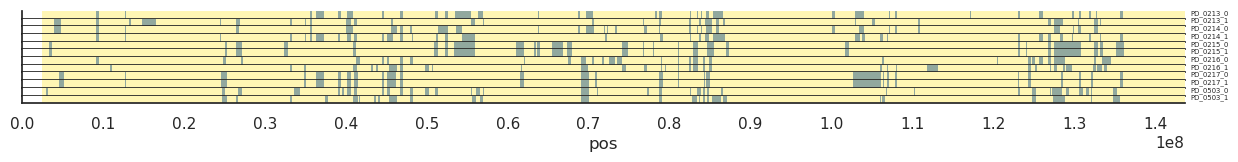

In [8]:
input_df = ruaha_df.loc[ruaha_df.chrom == "female_ref_chrX"]
input_df["haplo_ID"] = input_df.individual +"_"+ input_df.haplotype
input_df["is_north"] = [1 if x == 1 else 0 for x in input_df["n/s"]]
input_df["is_south"] = [1 if x == -1 else 0 for x in input_df["n/s"]]

def stairs(df, start='pos', end='end_pos', pos='pos', endtrim=0):
    "Turn a df with start, end into one with pos to plot as stairs"
    df1 = df.copy(deep=True)
    df2 = df.copy(deep=True)
    df1[pos] = df1[start]
    df2[pos] = df2[end] - endtrim
    return pd.concat([df1, df2]).sort_values([start, end])

g = sns.FacetGrid(stairs(input_df).sort_values(["pos", "haplo_ID"]), col='chrom', row='haplo_ID', sharex=True, sharey=True, height=0.1, aspect=150,
                    margin_titles=True, gridspec_kws={'hspace':0.0})
plot_df = stairs(input_df).sort_values(["pos", "haplo_ID"])
haplo_ID_sorting = input_df.haplo_ID.unique()

# Colors
hamadryas_north = '#91a89e'
olive_north = '#495F43'
yellow_south = '#FFF6B4'

g.map(plt.fill_between, 
    'pos', 
    'is_north', 
    y2=0,
    color=hamadryas_north,
    linewidth=0,
    capstyle='butt')
g.map(plt.fill_between, 
    'pos', 
    'is_south', 
    y2=0,
    color=yellow_south,
    linewidth=0,
    capstyle='butt')
g.set_titles(col_template="", row_template="")
g.set(yticklabels=[])  
g.set(ylabel=None)
g.tick_params(left=False)  # remove the ticks 
for label, ax in zip(haplo_ID_sorting, g.axes.flat):
    ax.set_xlim(plot_df.pos.min(), plot_df.pos.max())
    ax.set_ylim(0, 1)    
    ax.annotate(label, xy=(1.005 , 0.5), xycoords='axes fraction', ha='left', size=5)
    ax.set_xticks(np.arange(0, max(plot_df.pos)+1, 10000000))

In [9]:
c_df = length_df.loc[(length_df.chrom == "female_ref_chrX")]
c_df = c_df.rename(columns={"pos": "start", "end_pos": "end"})
dummy_added = pd.concat([c_df, add_dummy(c_df)]).reset_index()
dummy_added = dummy_added.loc[(dummy_added["n/s"] != -1)].copy()
df = dummy_added.groupby(['chrom', 'individual', 'haplotype'])[["end", "start"]].apply(north_sum).reset_index(drop=True, level=-1).reset_index()

In [10]:
for c in length_df.chrom.unique():
    output_file = rfmix_path + "{}.windows.txt".format(c)
    print(output_file)
    if os.path.exists(output_file) == False:
        c_df = length_df.loc[(length_df.chrom == c)]
        c_df = c_df.rename(columns={"pos": "start", "end_pos": "end"})
        dummy_added = pd.concat([c_df, add_dummy(c_df)]).reset_index()
        dummy_added = dummy_added.loc[(dummy_added["n/s"] != -1)].copy()
        df = dummy_added.groupby(['chrom', 'individual', 'haplotype'])[["end", "start"]].apply(north_sum).reset_index(drop=True, level=-1).reset_index()
        df.to_csv(output_file, index=False, sep="\t")

../steps/rfmix_gen100/tanzania_focus/chr1.windows.txt
../steps/rfmix_gen100/tanzania_focus/chr2.windows.txt
../steps/rfmix_gen100/tanzania_focus/chr3.windows.txt
../steps/rfmix_gen100/tanzania_focus/chr4.windows.txt
../steps/rfmix_gen100/tanzania_focus/chr5.windows.txt
../steps/rfmix_gen100/tanzania_focus/chr6.windows.txt
../steps/rfmix_gen100/tanzania_focus/chr7.windows.txt
../steps/rfmix_gen100/tanzania_focus/chr8.windows.txt
../steps/rfmix_gen100/tanzania_focus/chr9.windows.txt
../steps/rfmix_gen100/tanzania_focus/chr10.windows.txt
../steps/rfmix_gen100/tanzania_focus/chr11.windows.txt
../steps/rfmix_gen100/tanzania_focus/chr12.windows.txt
../steps/rfmix_gen100/tanzania_focus/chr13.windows.txt
../steps/rfmix_gen100/tanzania_focus/chr14.windows.txt
../steps/rfmix_gen100/tanzania_focus/chr15.windows.txt
../steps/rfmix_gen100/tanzania_focus/chr16.windows.txt
../steps/rfmix_gen100/tanzania_focus/chr17.windows.txt
../steps/rfmix_gen100/tanzania_focus/chr18.windows.txt
../steps/rfmix_gen1

And for the close pops

In [36]:
meta_data_samples = pd.read_csv("../data/Papio_metadata_with_clustering_sci.txt", sep =" ")
rfmix_path = "../steps/rfmix_gen100/tanzania_pure_focus_plain/"
mapping_df = pd.read_csv("../steps/rfmix_gen100/tanzania_pure_focus/" + "ref_names.txt", sep = "\t", names=["ID", "Origin"])

pop_mapping = {}
o_order = sorted((mapping_df.Origin.unique()))
for o in range(len((mapping_df.Origin.unique()))):
    pop_mapping[o_order[o]] = o
north_south_mapping = {'Gog Woreda, Gambella region, Ethiopia': 1,
 'Mikumi, Tanzania': -1,
 'Mahale, Tanzania': -1}

In [37]:
df_l = []
for chrom in ["chr{}".format(x) for x in (range(1, 21))]+["all_chrX", "female_chrX", "female_ref_chrX"]:
    print(chrom)
    input_file = rfmix_path + "{}.msp.tsv".format(chrom)
    chr_df = pd.read_csv(input_file, sep = "\t", header=1)
    file = open(input_file, 'r')
    line1 = file.readline()
    file.close()
    number_subpop_mapping = {}
    for subpop in line1.strip().split("\t"):
        # Splitting to create lists containing two values - subpop and number.
        subpop_number = subpop.split(": ")[-1].split("=")
        number_subpop_mapping[int(subpop_number[1])] = subpop_number[0]
    for hap in chr_df.columns[6:]:
        paint_df = create_paint_df_ind_compressed(chr_df, hap, number_subpop_mapping, north_south_mapping)
        paint_df["chrom"] = "{}".format(chrom)
        df_l.append(paint_df)
length_df = pd.concat(df_l)

chr1
chr2
chr3
chr4
chr5
chr6
chr7
chr8
chr9
chr10
chr11
chr12
chr13
chr14
chr15
chr16
chr17
chr18
chr19
chr20
all_chrX
female_chrX
female_ref_chrX


In [38]:
for c in length_df.chrom.unique():
    output_file = rfmix_path + "{}.windows.txt".format(c)
    print(output_file)
    if os.path.exists(output_file) == False:
        c_df = length_df.loc[(length_df.chrom == c)]
        c_df = c_df.rename(columns={"pos": "start", "end_pos": "end"})
        dummy_added = pd.concat([c_df, add_dummy(c_df)]).reset_index()
        dummy_added = dummy_added.loc[(dummy_added["n/s"] != -1)].copy()
        df = dummy_added.groupby(['chrom', 'individual', 'haplotype'])[["end", "start"]].apply(north_sum).reset_index(drop=True, level=-1).reset_index()
        df.to_csv(output_file, index=False, sep="\t")

../steps/rfmix_gen100/tanzania_pure_focus_plain/chr1.windows.txt
../steps/rfmix_gen100/tanzania_pure_focus_plain/chr2.windows.txt
../steps/rfmix_gen100/tanzania_pure_focus_plain/chr3.windows.txt
../steps/rfmix_gen100/tanzania_pure_focus_plain/chr4.windows.txt
../steps/rfmix_gen100/tanzania_pure_focus_plain/chr5.windows.txt
../steps/rfmix_gen100/tanzania_pure_focus_plain/chr6.windows.txt
../steps/rfmix_gen100/tanzania_pure_focus_plain/chr7.windows.txt
../steps/rfmix_gen100/tanzania_pure_focus_plain/chr8.windows.txt
../steps/rfmix_gen100/tanzania_pure_focus_plain/chr9.windows.txt
../steps/rfmix_gen100/tanzania_pure_focus_plain/chr10.windows.txt
../steps/rfmix_gen100/tanzania_pure_focus_plain/chr11.windows.txt
../steps/rfmix_gen100/tanzania_pure_focus_plain/chr12.windows.txt
../steps/rfmix_gen100/tanzania_pure_focus_plain/chr13.windows.txt
../steps/rfmix_gen100/tanzania_pure_focus_plain/chr14.windows.txt
../steps/rfmix_gen100/tanzania_pure_focus_plain/chr15.windows.txt
../steps/rfmix_gen1

And lastly for the ethiopian olives.

In [14]:
meta_data_samples = pd.read_csv("../data/Papio_metadata_with_clustering_sci.txt", sep =" ")
rfmix_path = "../steps/rfmix_gen100/eth_olive_focus/"
mapping_df = pd.read_csv(rfmix_path + "ref_names.txt", sep = "\t", names=["ID", "Origin"])

pop_mapping = {}
o_order = sorted((mapping_df.Origin.unique()))
for o in range(len((mapping_df.Origin.unique()))):
    pop_mapping[o_order[o]] = o
north_south_mapping = {'Hamadryas, Ethiopia': 1,
 'Cynocephalus, Central Tanzania': -1,
 'Papio, Senegal': -1,
 'Anubis, Tanzania': -1}

In [15]:
df_l = []
for chrom in ["chr{}".format(x) for x in (range(1, 21))]+["all_chrX", "female_chrX", "female_ref_chrX"]:
    print(chrom)
    input_file = rfmix_path + "{}.msp.tsv".format(chrom)
    chr_df = pd.read_csv(input_file, sep = "\t", header=1)
    file = open(input_file, 'r')
    line1 = file.readline()
    file.close()
    number_subpop_mapping = {}
    for subpop in line1.strip().split("\t"):
        # Splitting to create lists containing two values - subpop and number.
        subpop_number = subpop.split(": ")[-1].split("=")
        number_subpop_mapping[int(subpop_number[1])] = subpop_number[0]
    for hap in chr_df.columns[6:]:
        paint_df = create_paint_df_ind_compressed(chr_df, hap, number_subpop_mapping, north_south_mapping)
        paint_df["chrom"] = "{}".format(chrom)
        df_l.append(paint_df)
length_df = pd.concat(df_l)

chr1
chr2
chr3
chr4
chr5
chr6
chr7
chr8
chr9
chr10
chr11
chr12
chr13
chr14
chr15
chr16
chr17
chr18
chr19
chr20
all_chrX
female_chrX
female_ref_chrX


In [16]:
for c in length_df.chrom.unique():
    output_file = rfmix_path + "{}.windows.txt".format(c)
    print(output_file)
    if os.path.exists(output_file) == False:
        c_df = length_df.loc[(length_df.chrom == c)]
        c_df = c_df.rename(columns={"pos": "start", "end_pos": "end"})
        dummy_added = pd.concat([c_df, add_dummy(c_df)]).reset_index()
        dummy_added = dummy_added.loc[(dummy_added["n/s"] != -1)].copy()
        df = dummy_added.groupby(['chrom', 'individual', 'haplotype'])[["end", "start"]].apply(north_sum).reset_index(drop=True, level=-1).reset_index()
        df.to_csv(output_file, index=False, sep="\t")

../steps/rfmix_gen100/eth_olive_focus/chr1.windows.txt
../steps/rfmix_gen100/eth_olive_focus/chr2.windows.txt
../steps/rfmix_gen100/eth_olive_focus/chr3.windows.txt
../steps/rfmix_gen100/eth_olive_focus/chr4.windows.txt
../steps/rfmix_gen100/eth_olive_focus/chr5.windows.txt
../steps/rfmix_gen100/eth_olive_focus/chr6.windows.txt
../steps/rfmix_gen100/eth_olive_focus/chr7.windows.txt
../steps/rfmix_gen100/eth_olive_focus/chr8.windows.txt
../steps/rfmix_gen100/eth_olive_focus/chr9.windows.txt
../steps/rfmix_gen100/eth_olive_focus/chr10.windows.txt
../steps/rfmix_gen100/eth_olive_focus/chr11.windows.txt
../steps/rfmix_gen100/eth_olive_focus/chr12.windows.txt
../steps/rfmix_gen100/eth_olive_focus/chr13.windows.txt
../steps/rfmix_gen100/eth_olive_focus/chr14.windows.txt
../steps/rfmix_gen100/eth_olive_focus/chr15.windows.txt
../steps/rfmix_gen100/eth_olive_focus/chr16.windows.txt
../steps/rfmix_gen100/eth_olive_focus/chr17.windows.txt
../steps/rfmix_gen100/eth_olive_focus/chr18.windows.txt
.

I'm unsure if the reanalysis reference setting hinders the analysis, so I will try without.
After further investigation, I can say that reanalyze-reference does very little.

In [17]:
meta_data_samples = pd.read_csv("../data/Papio_metadata_with_clustering_sci.txt", sep =" ")
rfmix_path = "../steps/rfmix_gen100/eth_olive_focus_plain/"
mapping_df = pd.read_csv("../steps/rfmix_gen100/eth_olive_focus/" + "ref_names.txt", sep = "\t", names=["ID", "Origin"])

pop_mapping = {}
o_order = sorted((mapping_df.Origin.unique()))
for o in range(len((mapping_df.Origin.unique()))):
    pop_mapping[o_order[o]] = o
north_south_mapping = {'Hamadryas, Ethiopia': 1,
 'Cynocephalus, Central Tanzania': -1,
 'Papio, Senegal': -1,
 'Anubis, Tanzania': -1}

In [18]:
df_l = []
for chrom in ["chr{}".format(x) for x in (range(1, 21))]+["all_chrX", "female_chrX", "female_ref_chrX"]:
    print(chrom)
    input_file = rfmix_path + "{}.msp.tsv".format(chrom)
    chr_df = pd.read_csv(input_file, sep = "\t", header=1)
    file = open(input_file, 'r')
    line1 = file.readline()
    file.close()
    number_subpop_mapping = {}
    for subpop in line1.strip().split("\t"):
        # Splitting to create lists containing two values - subpop and number.
        subpop_number = subpop.split(": ")[-1].split("=")
        number_subpop_mapping[int(subpop_number[1])] = subpop_number[0]
    for hap in chr_df.columns[6:]:
        paint_df = create_paint_df_ind_compressed(chr_df, hap, number_subpop_mapping, north_south_mapping)
        paint_df["chrom"] = "{}".format(chrom)
        df_l.append(paint_df)
length_df = pd.concat(df_l)

chr1
chr2
chr3
chr4
chr5
chr6
chr7
chr8
chr9
chr10
chr11
chr12
chr13
chr14
chr15
chr16
chr17
chr18
chr19
chr20
all_chrX
female_chrX
female_ref_chrX


In [19]:
length_df.individual.unique()

array(['Sci_30877', 'Sci_30977', 'Sci_34449', 'Sci_34474', 'PD_0228',
       'PD_0229', 'PD_0230', 'PD_0231', 'PD_0232', 'PD_0233', 'PD_0234',
       'PD_0658', 'PD_0659', 'PD_0662', 'PD_0692', 'PD_0693', 'PD_0694',
       'PD_0695', 'PD_0720', 'PD_0721', 'PD_0722', 'PD_0723', 'PD_0724',
       'PD_0725', 'PD_0726', 'PD_0727', 'PD_0728', 'PD_0729', 'PD_0730',
       'PD_0731', 'PD_0732', 'PD_0733', 'PD_0734', 'PD_0735', 'PD_0736',
       'PD_0737', 'PD_0738', 'PD_0739', 'PD_0740', 'PD_0741', 'PD_0742',
       'PD_0743', 'PD_0744', 'PD_0749', 'PD_0750', 'PD_0751', 'PD_0758',
       'PD_0759', 'PD_0760', 'PD_0776', 'PD_0777', 'PD_0778', 'PD_0779',
       'PD_0780', 'PD_0781', 'PD_0782', 'PD_0783', 'PD_0784', 'PD_0785',
       'PD_0786', 'PD_0787', 'PD_0788', 'PD_0789', 'PD_0790', 'PD_0791',
       'PD_0792', 'PD_0793', 'PD_0794_BAB'], dtype=object)

In [20]:
PD_0732_df = length_df.loc[length_df.individual == "PD_0732"]
PD_0732_df.loc[PD_0732_df["n/s"] == 1].length.sum()/PD_0732_df.length.sum()

0.10826398203374527

In [21]:
PD_0732_df = length_df.loc[(length_df.individual == "PD_0732") & (length_df.chrom == "female_ref_chrX")]
PD_0732_df.loc[PD_0732_df["n/s"] == 1].length.sum()/PD_0732_df.length.sum()

0.2906054978982758

In [22]:
for c in length_df.chrom.unique():
    output_file = rfmix_path + "{}.windows.txt".format(c)
    print(output_file)
    if os.path.exists(output_file) == False:
        c_df = length_df.loc[(length_df.chrom == c)]
        c_df = c_df.rename(columns={"pos": "start", "end_pos": "end"})
        dummy_added = pd.concat([c_df, add_dummy(c_df)]).reset_index()
        dummy_added = dummy_added.loc[(dummy_added["n/s"] != -1)].copy()
        df = dummy_added.groupby(['chrom', 'individual', 'haplotype'])[["end", "start"]].apply(north_sum).reset_index(drop=True, level=-1).reset_index()
        df.to_csv(output_file, index=False, sep="\t")

../steps/rfmix_gen100/eth_olive_focus_plain/chr1.windows.txt
../steps/rfmix_gen100/eth_olive_focus_plain/chr2.windows.txt
../steps/rfmix_gen100/eth_olive_focus_plain/chr3.windows.txt
../steps/rfmix_gen100/eth_olive_focus_plain/chr4.windows.txt
../steps/rfmix_gen100/eth_olive_focus_plain/chr5.windows.txt
../steps/rfmix_gen100/eth_olive_focus_plain/chr6.windows.txt
../steps/rfmix_gen100/eth_olive_focus_plain/chr7.windows.txt
../steps/rfmix_gen100/eth_olive_focus_plain/chr8.windows.txt
../steps/rfmix_gen100/eth_olive_focus_plain/chr9.windows.txt
../steps/rfmix_gen100/eth_olive_focus_plain/chr10.windows.txt
../steps/rfmix_gen100/eth_olive_focus_plain/chr11.windows.txt
../steps/rfmix_gen100/eth_olive_focus_plain/chr12.windows.txt
../steps/rfmix_gen100/eth_olive_focus_plain/chr13.windows.txt
../steps/rfmix_gen100/eth_olive_focus_plain/chr14.windows.txt
../steps/rfmix_gen100/eth_olive_focus_plain/chr15.windows.txt
../steps/rfmix_gen100/eth_olive_focus_plain/chr16.windows.txt
../steps/rfmix_ge

In [23]:
meta_data_samples = pd.read_csv("../data/Papio_metadata_with_clustering_sci.txt", sep =" ")
rfmix_path = "../steps/rfmix_gen100/tanzania_focus_plain/"
mapping_df = pd.read_csv("../steps/rfmix_gen100/tanzania_focus/" + "ref_names.txt", sep = "\t", names=["ID", "Origin"])
pop_mapping = {}
o_order = sorted((mapping_df.Origin.unique()))
for o in range(len((mapping_df.Origin.unique()))):
    pop_mapping[o_order[o]] = o
    
north_south_mapping = {'Hamadryas, Ethiopia': 1,
 'Kindae, Zambia': -1,
 'Papio, Senegal': 1,
 'Ursinus, Zambia': -1}

In [24]:
df_l = []
for chrom in ["chr{}".format(x) for x in (range(1, 21))]+["all_chrX", "female_chrX", "female_ref_chrX"]:
    print(chrom)
    input_file = rfmix_path + "{}.msp.tsv".format(chrom)
    chr_df = pd.read_csv(input_file, sep = "\t", header=1)
    file = open(input_file, 'r')
    line1 = file.readline()
    file.close()
    number_subpop_mapping = {}
    for subpop in line1.strip().split("\t"):
        # Splitting to create lists containing two values - subpop and number.
        subpop_number = subpop.split(": ")[-1].split("=")
        number_subpop_mapping[int(subpop_number[1])] = subpop_number[0]
    for hap in chr_df.columns[6:]:
        paint_df = create_paint_df_ind_compressed(chr_df, hap, number_subpop_mapping, north_south_mapping)
        paint_df["chrom"] = "{}".format(chrom)
        df_l.append(paint_df)
length_df = pd.concat(df_l)

chr1
chr2
chr3
chr4
chr5
chr6
chr7
chr8
chr9
chr10
chr11
chr12
chr13
chr14
chr15
chr16
chr17
chr18
chr19
chr20
all_chrX
female_chrX
female_ref_chrX


In [25]:
for c in length_df.chrom.unique():
    output_file = rfmix_path + "{}.windows.txt".format(c)
    print(output_file)
    if os.path.exists(output_file) == False:
        c_df = length_df.loc[(length_df.chrom == c)]
        c_df = c_df.rename(columns={"pos": "start", "end_pos": "end"})
        dummy_added = pd.concat([c_df, add_dummy(c_df)]).reset_index()
        dummy_added = dummy_added.loc[(dummy_added["n/s"] != -1)].copy()
        df = dummy_added.groupby(['chrom', 'individual', 'haplotype'])[["end", "start"]].apply(north_sum).reset_index(drop=True, level=-1).reset_index()
        df.to_csv(output_file, index=False, sep="\t")

../steps/rfmix_gen100/tanzania_focus_plain/chr1.windows.txt
../steps/rfmix_gen100/tanzania_focus_plain/chr2.windows.txt
../steps/rfmix_gen100/tanzania_focus_plain/chr3.windows.txt
../steps/rfmix_gen100/tanzania_focus_plain/chr4.windows.txt
../steps/rfmix_gen100/tanzania_focus_plain/chr5.windows.txt
../steps/rfmix_gen100/tanzania_focus_plain/chr6.windows.txt
../steps/rfmix_gen100/tanzania_focus_plain/chr7.windows.txt
../steps/rfmix_gen100/tanzania_focus_plain/chr8.windows.txt
../steps/rfmix_gen100/tanzania_focus_plain/chr9.windows.txt
../steps/rfmix_gen100/tanzania_focus_plain/chr10.windows.txt
../steps/rfmix_gen100/tanzania_focus_plain/chr11.windows.txt
../steps/rfmix_gen100/tanzania_focus_plain/chr12.windows.txt
../steps/rfmix_gen100/tanzania_focus_plain/chr13.windows.txt
../steps/rfmix_gen100/tanzania_focus_plain/chr14.windows.txt
../steps/rfmix_gen100/tanzania_focus_plain/chr15.windows.txt
../steps/rfmix_gen100/tanzania_focus_plain/chr16.windows.txt
../steps/rfmix_gen100/tanzania_fo

In [26]:
meta_data_samples = pd.read_csv("../data/Papio_metadata_with_clustering_sci.txt", sep =" ")
rfmix_path = "../steps/rfmix_gen100/tanzania_gm_focus_plain/"
mapping_df = pd.read_csv("../steps/rfmix_gen100/tanzania_close_focus/" + "ref_names.txt", sep = "\t", names=["ID", "Origin"])

pop_mapping = {}
o_order = sorted((mapping_df.Origin.unique()))
for o in range(len((mapping_df.Origin.unique()))):
    pop_mapping[o_order[o]] = o
north_south_mapping = {'Gog Woreda, Gambella region, Ethiopia': 1,
 'Mikumi, Tanzania': -1}

In [27]:
df_l = []
for chrom in ["chr{}".format(x) for x in (range(1, 21))]+["all_chrX", "female_chrX", "female_ref_chrX"]:
    print(chrom)
    input_file = rfmix_path + "{}.msp.tsv".format(chrom)
    chr_df = pd.read_csv(input_file, sep = "\t", header=1)
    file = open(input_file, 'r')
    line1 = file.readline()
    file.close()
    number_subpop_mapping = {}
    for subpop in line1.strip().split("\t"):
        # Splitting to create lists containing two values - subpop and number.
        subpop_number = subpop.split(": ")[-1].split("=")
        number_subpop_mapping[int(subpop_number[1])] = subpop_number[0]
    for hap in chr_df.columns[6:]:
        paint_df = create_paint_df_ind_compressed(chr_df, hap, number_subpop_mapping, north_south_mapping)
        paint_df["chrom"] = "{}".format(chrom)
        df_l.append(paint_df)
length_df = pd.concat(df_l)

chr1
chr2
chr3
chr4
chr5
chr6
chr7
chr8
chr9
chr10
chr11
chr12
chr13
chr14
chr15
chr16
chr17
chr18
chr19
chr20
all_chrX
female_chrX
female_ref_chrX


In [28]:
meta_data_samples = pd.read_csv("../data/Papio_metadata_with_clustering_sci.txt", sep =" ")
rfmix_path = "../steps/rfmix_gen100/tanzania_gm_focus/"
mapping_df = pd.read_csv("../steps/rfmix_gen100/tanzania_close_focus/" + "ref_names.txt", sep = "\t", names=["ID", "Origin"])

pop_mapping = {}
o_order = sorted((mapping_df.Origin.unique()))
for o in range(len((mapping_df.Origin.unique()))):
    pop_mapping[o_order[o]] = o
north_south_mapping = {'Gog Woreda, Gambella region, Ethiopia': 1,
 'Mikumi, Tanzania': -1}

In [29]:
df_l = []
for chrom in ["chr{}".format(x) for x in (range(1, 21))]+["all_chrX", "female_chrX", "female_ref_chrX"]:
    print(chrom)
    input_file = rfmix_path + "{}.msp.tsv".format(chrom)
    chr_df = pd.read_csv(input_file, sep = "\t", header=1)
    file = open(input_file, 'r')
    line1 = file.readline()
    file.close()
    number_subpop_mapping = {}
    for subpop in line1.strip().split("\t"):
        # Splitting to create lists containing two values - subpop and number.
        subpop_number = subpop.split(": ")[-1].split("=")
        number_subpop_mapping[int(subpop_number[1])] = subpop_number[0]
    for hap in chr_df.columns[6:]:
        paint_df = create_paint_df_ind_compressed(chr_df, hap, number_subpop_mapping, north_south_mapping)
        paint_df["chrom"] = "{}".format(chrom)
        df_l.append(paint_df)
length_df = pd.concat(df_l)

chr1
chr2
chr3
chr4
chr5
chr6
chr7
chr8
chr9
chr10
chr11
chr12
chr13
chr14
chr15
chr16
chr17
chr18
chr19
chr20
all_chrX
female_chrX
female_ref_chrX


In [30]:
for c in length_df.chrom.unique():
    output_file = rfmix_path + "{}.windows.txt".format(c)
    print(output_file)
    if os.path.exists(output_file) == False:
        c_df = length_df.loc[(length_df.chrom == c)]
        c_df = c_df.rename(columns={"pos": "start", "end_pos": "end"})
        dummy_added = pd.concat([c_df, add_dummy(c_df)]).reset_index()
        dummy_added = dummy_added.loc[(dummy_added["n/s"] != -1)].copy()
        df = dummy_added.groupby(['chrom', 'individual', 'haplotype'])[["end", "start"]].apply(north_sum).reset_index(drop=True, level=-1).reset_index()
        df.to_csv(output_file, index=False, sep="\t")

../steps/rfmix_gen100/tanzania_gm_focus/chr1.windows.txt
../steps/rfmix_gen100/tanzania_gm_focus/chr2.windows.txt
../steps/rfmix_gen100/tanzania_gm_focus/chr3.windows.txt
../steps/rfmix_gen100/tanzania_gm_focus/chr4.windows.txt
../steps/rfmix_gen100/tanzania_gm_focus/chr5.windows.txt
../steps/rfmix_gen100/tanzania_gm_focus/chr6.windows.txt
../steps/rfmix_gen100/tanzania_gm_focus/chr7.windows.txt
../steps/rfmix_gen100/tanzania_gm_focus/chr8.windows.txt
../steps/rfmix_gen100/tanzania_gm_focus/chr9.windows.txt
../steps/rfmix_gen100/tanzania_gm_focus/chr10.windows.txt
../steps/rfmix_gen100/tanzania_gm_focus/chr11.windows.txt
../steps/rfmix_gen100/tanzania_gm_focus/chr12.windows.txt
../steps/rfmix_gen100/tanzania_gm_focus/chr13.windows.txt
../steps/rfmix_gen100/tanzania_gm_focus/chr14.windows.txt
../steps/rfmix_gen100/tanzania_gm_focus/chr15.windows.txt
../steps/rfmix_gen100/tanzania_gm_focus/chr16.windows.txt
../steps/rfmix_gen100/tanzania_gm_focus/chr17.windows.txt
../steps/rfmix_gen100/t